In this code I apply the state estimation algorithm implemented in `utils/state_estimation.py` to estimate the state of custom generated data of a simulation with a quad robot as in `examples/mjx_quad.py`.

### Imports and loading data

In [1]:
import numpy as np
from pathlib import Path
import utils.state_estimation
from utils.plot_data import *
from gym_quadruped.quadruped_env import QuadrupedEnv
import mujoco
from tqdm import tqdm
from rosbags.highlevel import AnyReader
from rosbags.typesys import get_typestore, Stores
from pathlib import Path
import numpy as np
from utils.ekf_utils import *

sim_num = 3
dataset_num = 2
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)
num_datasets = data["num_datasets"]
num_datapoints = data["num_datapoints"]

Data loaded from /home/undefined/Uni/semester-2/RL-IP_Part-1/mpx/custom_datasets/quad_dataset_run2.npz.


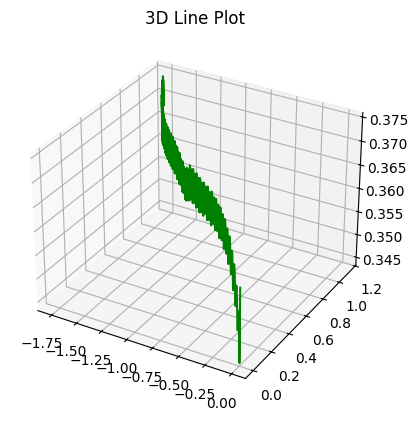

In [37]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.axes(projection='3d')
base_pos = data["base_pos"]

x = base_pos[:, 0]
y = base_pos[:, 1]
z = base_pos[:, 2]

ax.plot3D(x, y, z, 'green')
ax.set_title('3D Line Plot')
plt.show()

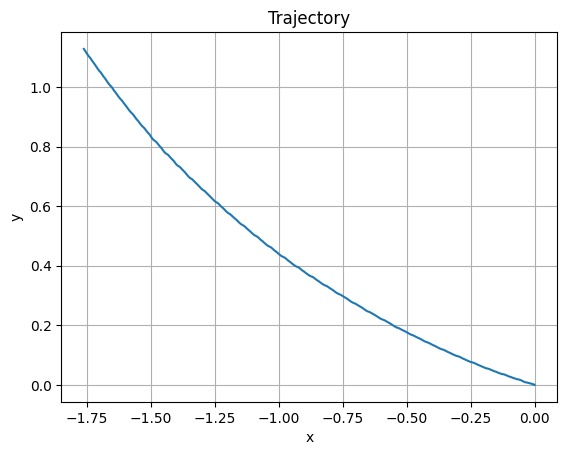

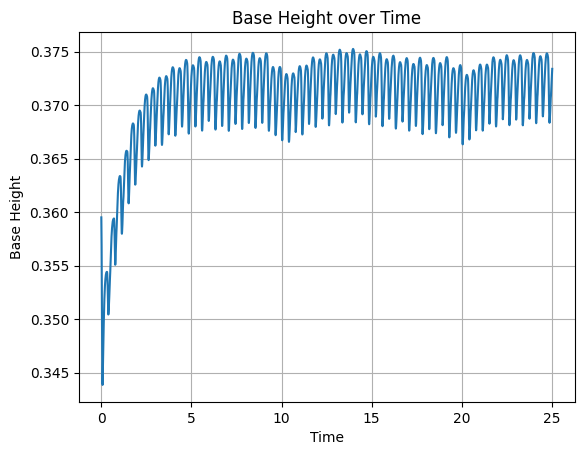

In [38]:
base_plot(data["time"], data["base_pos"])

## State Estimation (With measured base acceleration)

In [4]:
print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

# case 1: everything is given
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_acc=data["base_acc"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               contact_states=data["contact_states"],
#                               contact_forces=data["contact_forces"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# base acc has to be estimated
# case 2: from measured contact force and state
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               contact_states=data["contact_states"],
#                               contact_forces=data["contact_forces"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# # case 3: from estimated contact force from jacobian and joint torque
# result = run_state_estimation(dt=data["dt"][0],
#                               base_pos=data["base_pos"],
#                               base_orient=data["base_orient"],
#                               base_ang_vel=data["base_ang_vel"],
#                               joint_pos=data["joint_pos"],
#                               joint_vel=data["joint_vel"],
#                               joint_torque=data["joint_torque"],
#                               contact_states=data["contact_states"],
#                               contact_pos=data["contact_pos"],
#                               Q=0.002, 
#                               R=0.01,)

# # case 4: from measured contact force, joint torque and estimated contact state based of force
result = run_state_estimation(dt=data["dt"][0],
                              base_pos=data["base_pos"],
                              base_orient=data["base_orient"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_torque=data["joint_torque"],
                              contact_forces=data["contact_forces"],
                              contact_pos=data["contact_pos"],
                              Q=0.002, 
                              R=0.01,)

# case 5 (Leg-KILO): using measured force (single value) to estimate state and joint torque to estimate real contact force

==================== Simulation no. 2 ====================
Estimating base_acc.
Estimating state from contact_force and threshold


Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 2300.00it/s]


In [2]:
print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

# case 1: everything is given
result = run_state_estimation(dt=data["dt"][0],
                              base_pos=data["base_pos"],
                              base_orient=data["base_orient"],
                              base_acc=data["base_acc"],
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              contact_states=data["contact_states"],
                              contact_forces=data["contact_forces"],
                              contact_pos=data["contact_pos"],
                              Q=0.01, 
                              R=0.001)

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


==================== Simulation no. 4 ====================


Estimating state: 100%|██████████| 5000/5000 [00:01<00:00, 2597.10it/s]


### Position

In [22]:
A = np.concatenate([np.concatenate([np.eye(3), 0.005 * np.eye(3)], axis=1), np.concatenate([np.zeros((3,3)), np.eye(3)], axis=1)]) # state transition matrix
x = np.concatenate([np.zeros(3), np.ones((3,))])

B = np.concatenate([np.zeros(3), np.full(3, 0.005)])
u = np.concatenate([np.zeros(3), np.ones((3,))])

a2 = A @ x
a1 = B * u

a2 + a1

array([0.005, 0.005, 0.005, 1.005, 1.005, 1.005])

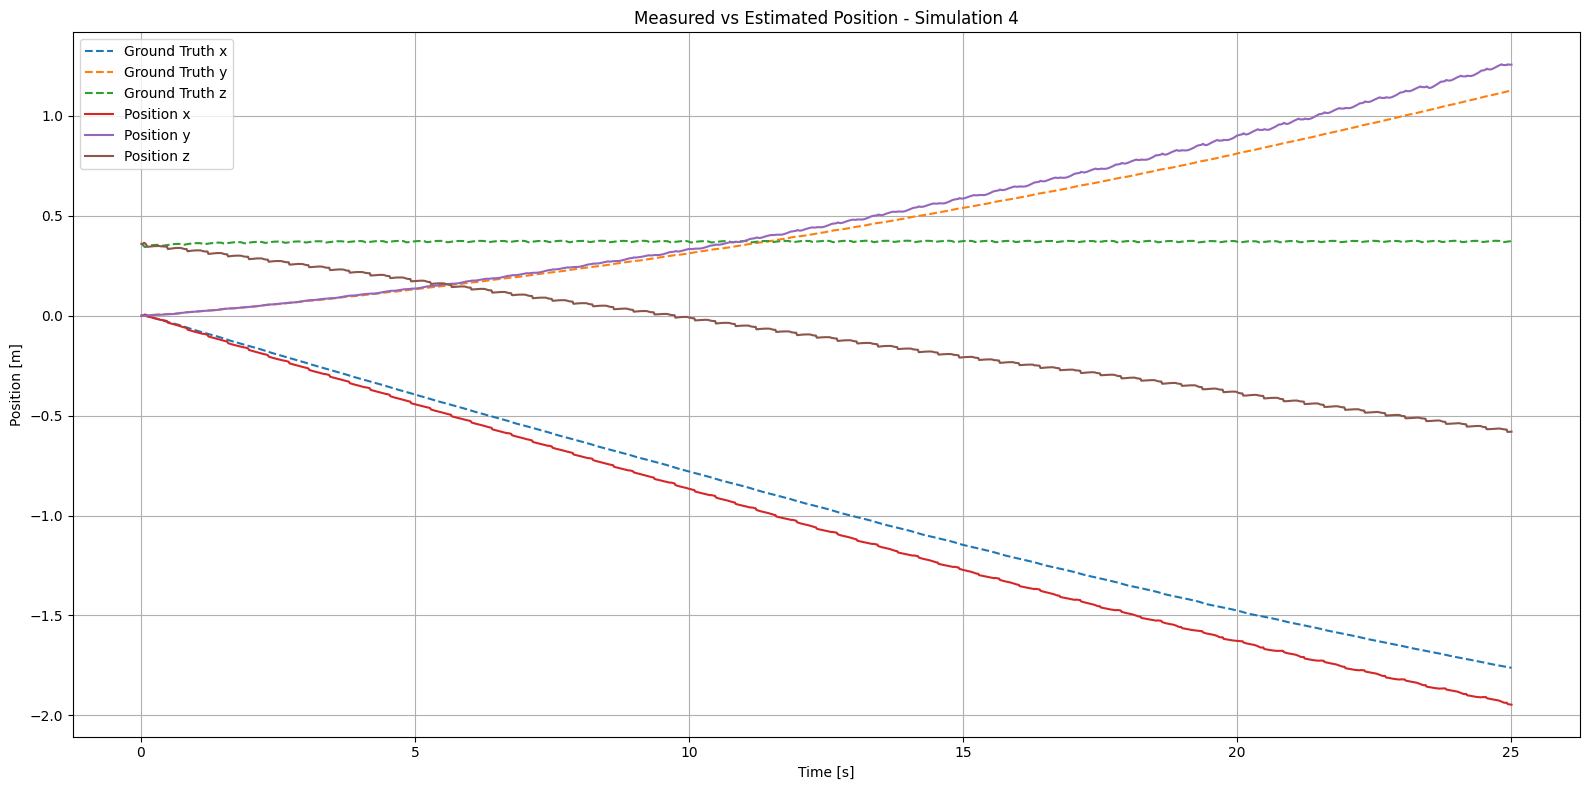

In [9]:
# --- Estimated Position ---
# estimation_error(ground_truth=data["base_pos"], estimation=result["pos_update"], title="Position")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_pos"],
                        pred_values=[result["pos_update"]],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position - Simulation {sim_num+1}"
                        )

In [ ]:
# --- Position from leg odom velocity ---
integr_pos = compute_pos_from_estimated_vel(result["leg_odom"], data["dt"][0])

estimation_error(ground_truth=data["base_pos"], estimation=integr_pos, title="Position")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_pos"],
                        pred_values=[integr_pos],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position (vel from leg odom) - Simulation {sim_num+1}"
                        )

In [ ]:
# --- Position from ekf velocity ---
integr_pos = compute_pos_from_estimated_vel(result["vel_update"], data["dt"][0])

estimation_error(ground_truth=data["base_pos"], estimation=integr_pos, title="Position")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_pos"],
                        pred_values=[integr_pos],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position (vel from ekf) - Simulation {sim_num+1}"
                        )

### Velocity

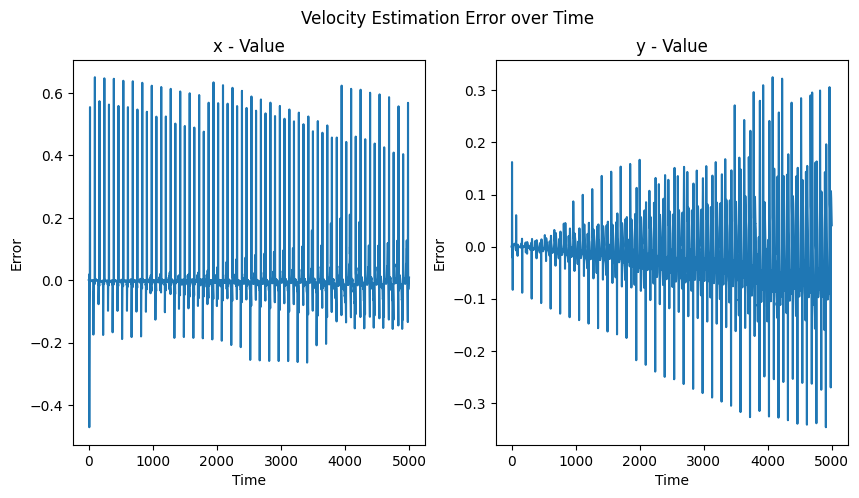

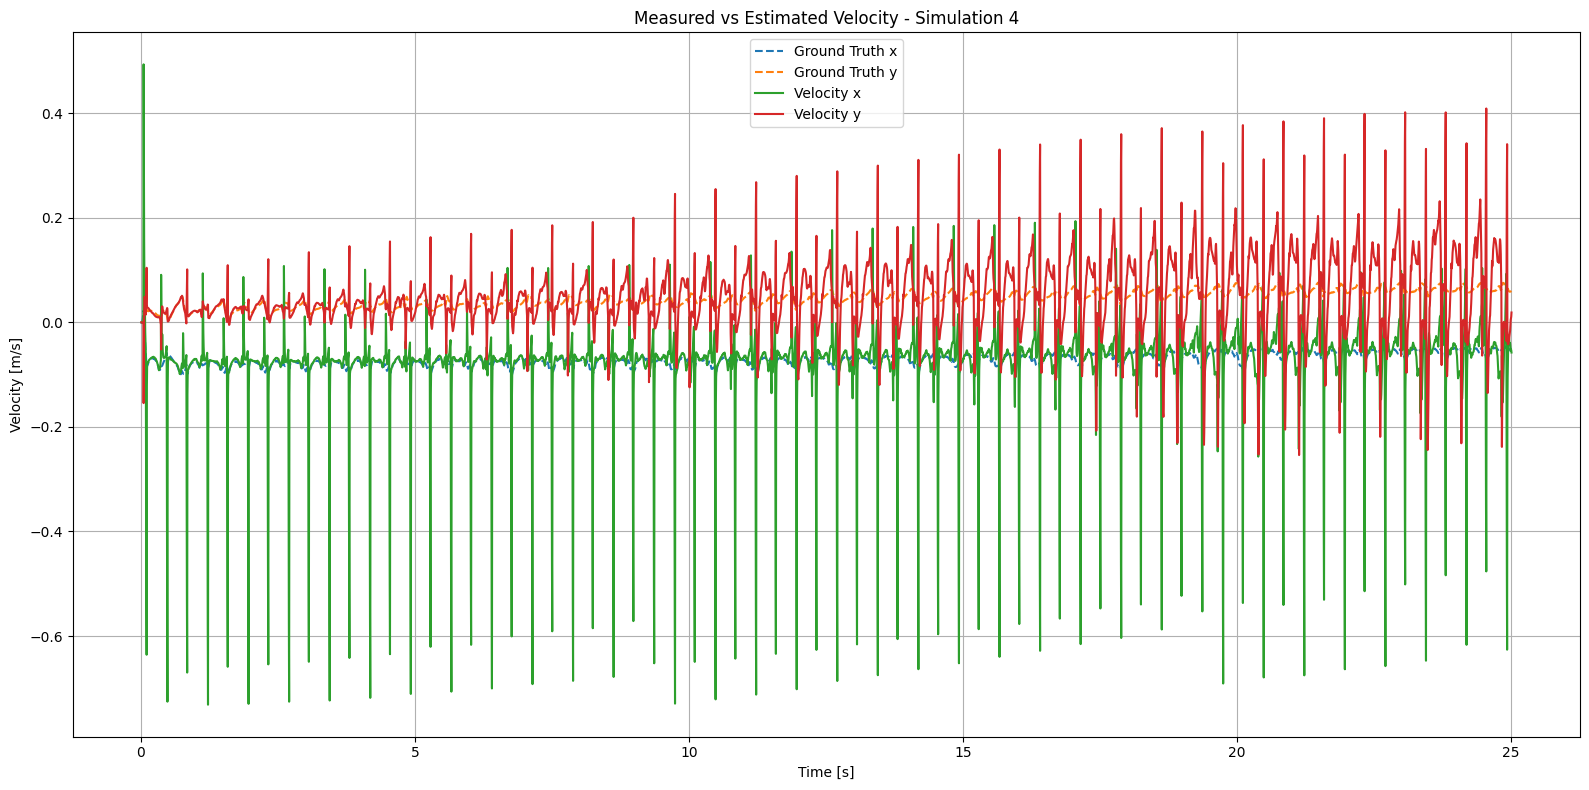

In [23]:
# --- Estimated Velocity ---
estimation_error(ground_truth=data["base_vel"][:, :2], estimation=result["vel_update"][:, :2], title="Velocity")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_vel"][:, :2],
                        pred_values=[result["vel_update"][:, :2]],
                        pred_labels=["Velocity"],
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity - Simulation {sim_num+1}"
                        )

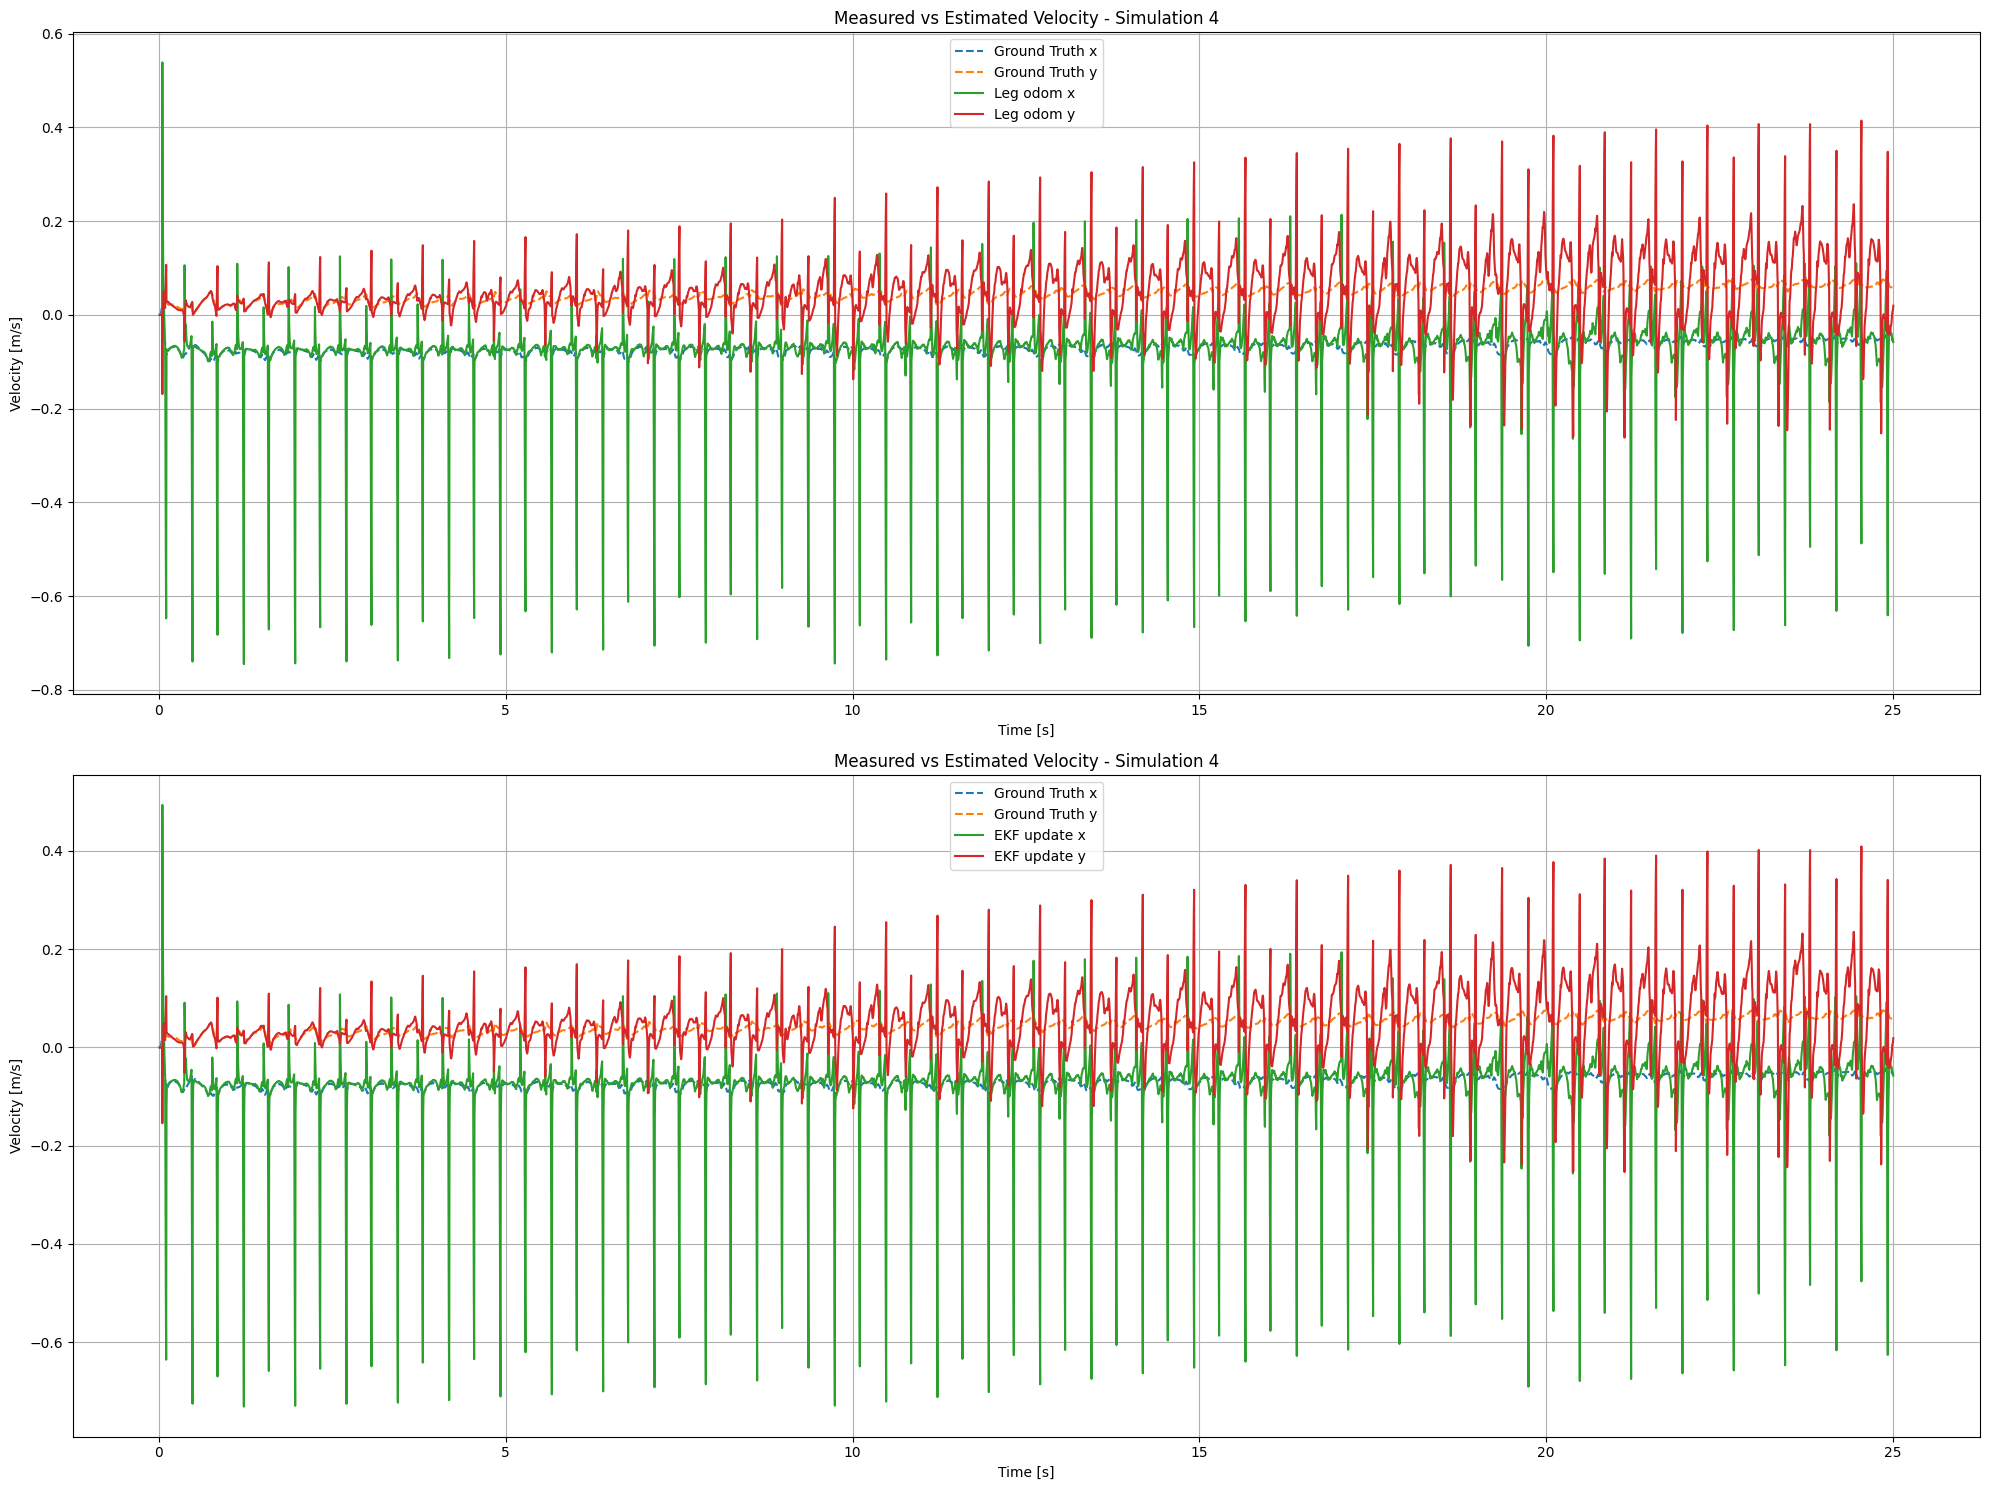

In [24]:
# --- Velocity leg odom, EKF and gt ---
predictions = [result["leg_odom"][:, :2], result["vel_update"][:, :2]]
pred_labels = ["Leg odom", "EKF update"]

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_vel"][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity - Simulation {sim_num+1}",
                        combined_plot=False
                        )

## State Estimation (With estimated acceleration from contact force)

In [ ]:
print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

result = run_state_estimation(dt=data["dt"][0],
                              base_pos=data["base_pos"],
                              base_orient=data["base_orient"],
                              base_acc=None,
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              contact_states=data["contact_states"],
                              contact_forces=data["contact_forces"],
                              contact_pos=data["contact_pos"],
                              Q=0.002, 
                              R=0.01,
                              dataset_size=data["num_datapoints"],
                              acc_from_contact_force=True)

In [ ]:
# --- Velocity leg odom, EKF and gt ---
predictions = [result["leg_odom"][:, :2], result["vel_update"][:, :2]]
pred_labels = ["Leg odom", "EKF update"]

estimation_error(ground_truth=data["base_vel"][:, :2], estimation=result["vel_update"][:, :2], title="Velocity")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_vel"][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Simulation {sim_num+1}",
                        combined_plot=False
                        )

## State Estimation (With estimated acceleration from estimated contact force)

In [ ]:
print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

result = run_state_estimation(dt=data["dt"][0],
                              base_pos=data["base_pos"],
                              base_orient=data["base_orient"],
                              base_acc=None,
                              base_ang_vel=data["base_ang_vel"],
                              joint_pos=data["joint_pos"],
                              joint_vel=data["joint_vel"],
                              joint_torque=data["joint_torque"],
                              contact_states=data["contact_states"],
                              contact_forces=None,
                              contact_pos=data["contact_pos"],
                              Q=0.002, 
                              R=0.01,
                              dataset_size=data["num_datapoints"],
                              acc_from_est_contact_force=True)

In [ ]:
# --- Velocity leg odom, EKF and gt ---
predictions = [result["leg_odom"][:, :2], result["vel_update"][:, :2]]
pred_labels = ["Leg odom", "EKF update"]

estimation_error(ground_truth=data["base_vel"][:, :2], estimation=result["vel_update"][:, :2], title="Velocity")

compare_estimation_plot(time=data["time"],
                        gt_values=data["base_vel"][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Simulation {sim_num+1}",
                        combined_plot=False
                        )

## State Estimation (With data from publicly available dataset Leg-KILO)

https://github.com/ShuoYangRobotics/Cerberus

Interesting topics:
- **/hardware_a1/imu**: internal robot IMU (raw)
    - orientation, angular_velocity, linear acceleration (filtered)
- **/imu/data**: sensorfusion, orientation computed from gyro and acc
    - orientation, angular_velocity, linear acceleration
- **/hardware_a1/joint_foot**
    - name, position, velocity
- **/mocap_node/mocap/pose**
    -pose.position, pose.orientation

---

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)
- contact_pos 

https://github.com/ouguangjun/legkilo-dataset

Interesting topics:
- **/high_state**

In [20]:
def dump(obj, prefix=""):
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            dump(v, f"{prefix}{k}.")
    else:
        print(prefix[:-1], "=", obj)

bagpath = Path("../custom_datasets/corridor.bag")
typestore = get_typestore(Stores.ROS2_KILTED)

with AnyReader([bagpath]) as reader:
    print(30*"=", "Topics", 30*"=")
    topics_of_interest = []

    # read topics from .bag file
    for c in reader.connections:
        print(f"{c.topic:40s}  {c.msgtype}")
        topics_of_interest.append(c.topic)
    
    for topic_of_interest in topics_of_interest:
        conns = [c for c in reader.connections if c.topic == topic_of_interest]
        if not conns:
            raise RuntimeError(f"Topic not found: {topic_of_interest}")

        for conn, t, raw in reader.messages(connections=conns):
            msg = reader.deserialize(raw, conn.msgtype)
            print(f"\n{20*"="} Example for {conn.topic} ({conn.msgtype}) {20*"="}")
            dump(msg)
            if conn.topic == "/high_state":
                print("000000000")
                footForce = msg.footForce
                break
            break

============================== Topics ==============================
/high_state                               unitree_legged_msgs/msg/HighState
/state_SDK                                nav_msgs/msg/Odometry
/imu_raw                                  sensor_msgs/msg/Imu
/points_raw                               sensor_msgs/msg/PointCloud2

==================== Example for /high_state (unitree_legged_msgs/msg/HighState) ====================
stamp.sec = 1684325646
stamp.nanosec = 562455592
stamp.__msgtype__ = builtin_interfaces/msg/Time
head = [254 239]
levelFlag = 238
frameReserve = 0
SN = [100729604     66077]
version = [    590080 2146969345]
bandWidth = 250
imu.quaternion = [-0.01335226  0.01234161 -0.7031739   0.71078545]
imu.gyroscope = [-0.00191184 -0.01583053 -0.00426268]
imu.accelerometer = [ 1.1971008e-03 -3.1723171e-01  9.6558151e+00]
imu.rpy = [-3.6345810e-02 -1.2334518e-03 -1.5600076e+00]
imu.temperature = 79
imu.__msgtype__ = unitree_legged_msgs/msg/IMU
motorState = [unitre

In [ ]:
def dump(obj, prefix=""):
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            dump(v, f"{prefix}{k}.")
    else:
        print(prefix[:-1], "=", obj)

bagpath = Path("../custom_datasets/corridor.bag")
typestore = get_typestore(Stores.ROS2_KILTED)

base_orient = []
base_ang_vel = []
base_acc = []
joint_pos = []
joint_vel = []
joint_torque = []
foot_force = []
contact_pos = []
time_state = []

with AnyReader([bagpath]) as reader:
    for connection, timestamp, rawdata in tqdm(reader.messages(), desc="Reading ROS .bag file", total=670538):
        msg = reader.deserialize(rawdata, connection.msgtype)

        if connection.topic == '/high_state':
            motor_state = msg.motorState
            joint_pos_curr = []
            joint_vel_curr = []
            joint_torque_curr = []
            foot_pos = []

            for i in range(12):
                ms = motor_state[i]
                joint_pos_curr.append(ms.q)
                joint_vel_curr.append(ms.dq)
                joint_torque_curr.append(ms.tauEst)
            
            for foot in msg.footPosition2Body:
                foot_pos.append([foot.x, foot.y, foot.z])
            
            joint_pos.append(joint_pos_curr)
            joint_vel.append(joint_vel_curr)
            joint_torque.append(joint_torque_curr)
            foot_force.append([float(x) for x in msg.footForce])
            contact_pos.append(foot_pos)
            time_state.append(timestamp*1e-9)
        
        if connection.topic == "/imu_raw":
            orient = [msg.orientation.x, msg.orientation.y, msg.orientation.z, msg.orientation.w]
            angvel = [msg.angular_velocity.x, msg.angular_velocity.y, msg.angular_velocity.z]
            linacc = [msg.linear_acceleration.x, msg.linear_acceleration.y, msg.linear_acceleration.z]
            
            base_orient.append(orient)
            base_ang_vel.append(angvel)
            base_acc.append(linacc)
        

Reading ROS .bag file: 100%|██████████| 670538/670538 [00:24<00:00, 27252.93it/s]


In [ ]:
force_np = np.array(foot_force)
time_state = np.array(time_state)
time_state -= time_state[0]

plot_len = 222039
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10,10))

for i in range(4):
    axs[i].plot(time_state[10000:11000], force_np[10000:11000, i])
    axs[i].set_ylabel(f'Foot {i}')

axs[-1].set_xlabel('Time [s]')

# plt.tight_layout()
plt.show()

In [28]:
result = run_state_estimation(dt=0.1,
                              base_acc=base_acc,
                              base_orient=base_orient,
                              base_ang_vel=base_ang_vel,
                              joint_pos=joint_pos,
                              joint_vel=joint_vel,
                              contact_forces=np.array(foot_force),
                              joint_torque=joint_torque,
                              contact_pos=contact_pos,
                              contact_state_threshold=600,
                              Q=0.002, 
                              R=0.01)

Values missing. Can't compute EKF without contact_force and contact_state.


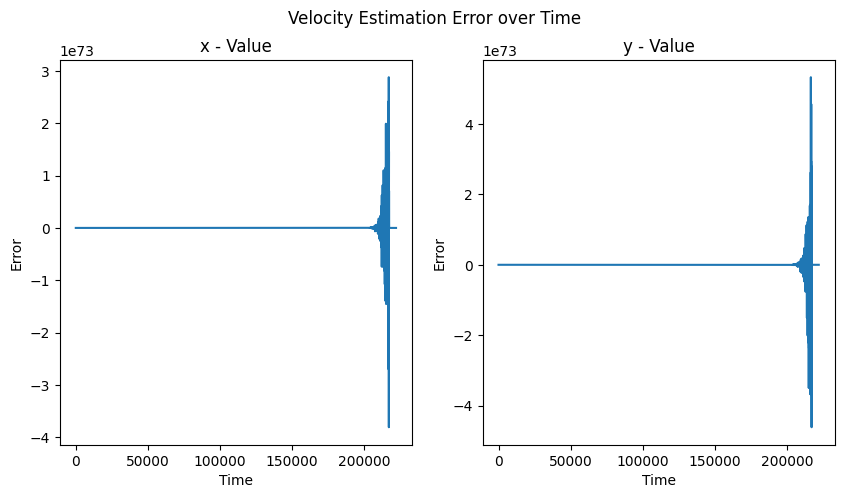

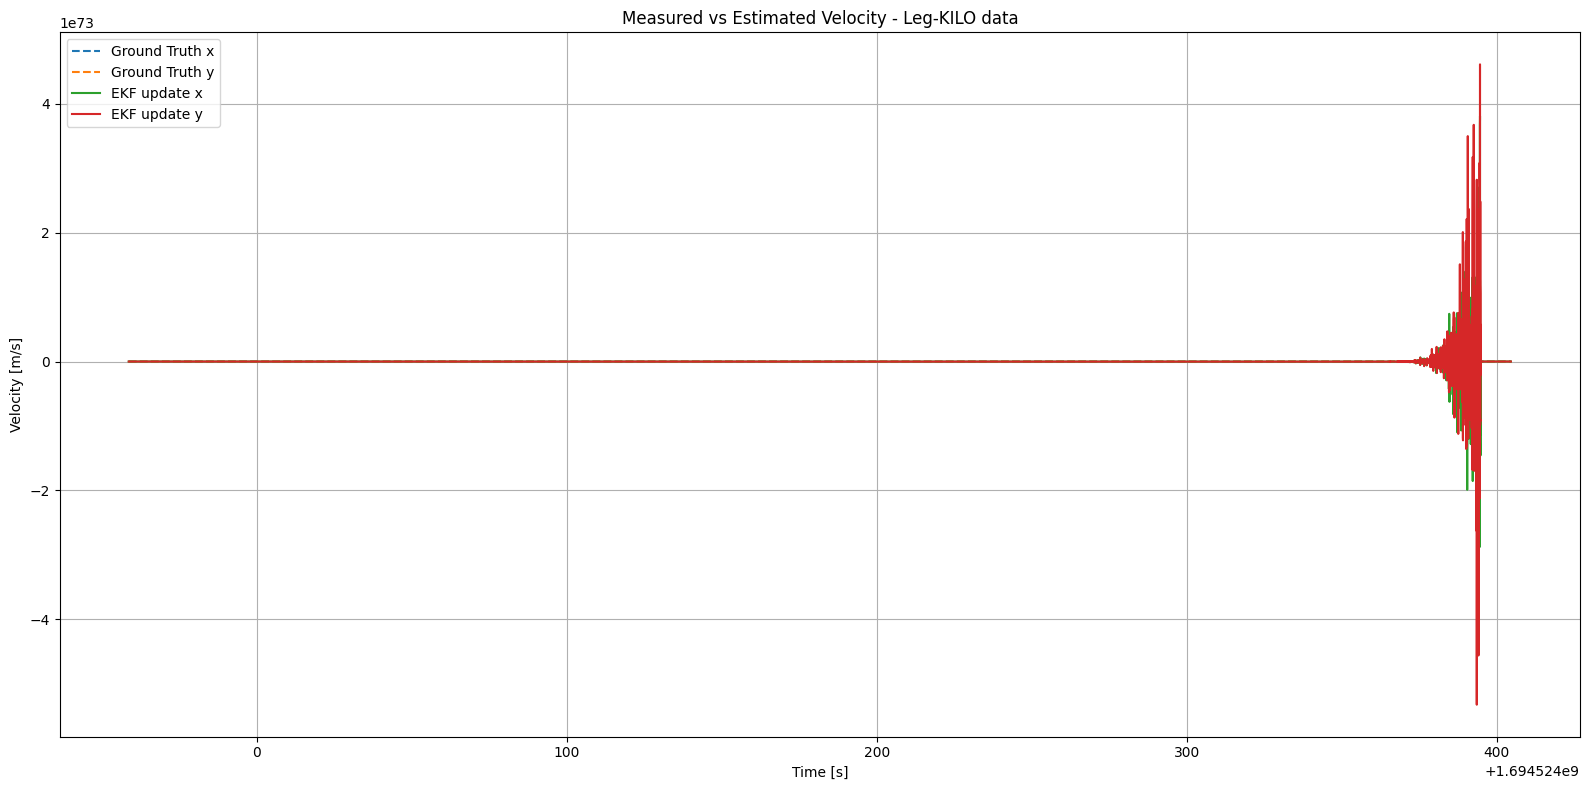

In [ ]:
# --- Velocity leg odom, EKF and gt ---
predictions = [result["vel_update"][:, :2]]
pred_labels = ["EKF update"]
gt_vel = np.array(base_vel)

estimation_error(ground_truth=gt_vel[:, :2], estimation=result["vel_update"][:, :2], title="Velocity")

compare_estimation_plot(time=time_state,
                        gt_values=gt_vel[:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity - Leg-KILO data"
                        )

https://ieeexplore.ieee.org/document/10802030

https://www.numberanalytics.com/blog/ultimate-kalman-filter-practice

https://web.stanford.edu/class/ee363/lectures/kf.pdf